In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tqdm.keras import TqdmCallback
from scipy.signal import savgol_filter


np.random.seed(42)
tf.random.set_seed(42)



df = pd.read_table("C:\\Users\\Adriel\\Desktop\\pesquisa\\Hz.txt", sep =' ', header = 0)

# redshifts 
z = df["z"].values

# errors
sigma = df["σH"].values



def Hubble(z, H0, Om0):

    Ode0 = 1.0 - Om0

    return H0 * np.sqrt(Om0 * (1 + z)**3 + (1.0 - Om0))



H_true = Hubble(z, 69, 0.29)


H_mock = H_true + np.random.normal(0, sigma)




indices = np.random.permutation(len(z))

split = int(0.8 * len(z))

train_idx = indices[:split]
test_idx  = indices[split:]

z_train = z[train_idx]
z_test  = z[test_idx]

H_train = H_mock[train_idx]
H_test  = H_mock[test_idx]

X_train = z_train.reshape(-1,1)
X_test  = z_test.reshape(-1,1)

# Neural Network

model = Sequential([

    Input(shape=(1,)),

    Dense(512, activation='elu'),
    Dense(512, activation='elu'),
    Dense(512, activation='elu'),

    Dense(1)])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='mae')


# Early Stoping


early_stop = EarlyStopping(

    monitor='val_loss',

    patience=300,

    restore_best_weights=True)


# Training


history = model.fit(

    X_train,
    H_train,

    validation_data=(X_test, H_test),

    epochs=5000,

    batch_size=16,

    verbose=0,

    callbacks=[TqdmCallback(verbose=1), early_stop])


# Reconstruction


z_grid = np.linspace(np.min(z),np.max(z),1000)

H_pred = model.predict(z_grid, verbose=0).flatten()

H_real = Hubble(z_grid, H0=70, Om0=0.3)



c:\Users\Adriel\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 54%|█████▎    | 2683/5000 [04:40<04:01,  9.58epoch/s, loss=7.88, val_loss=10.9]


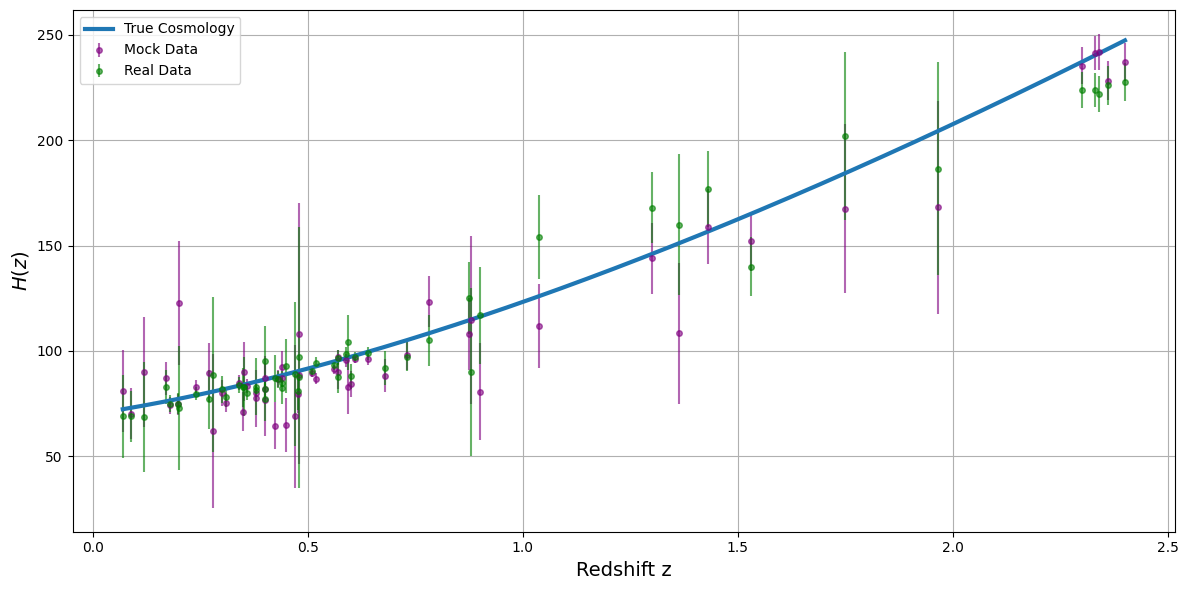

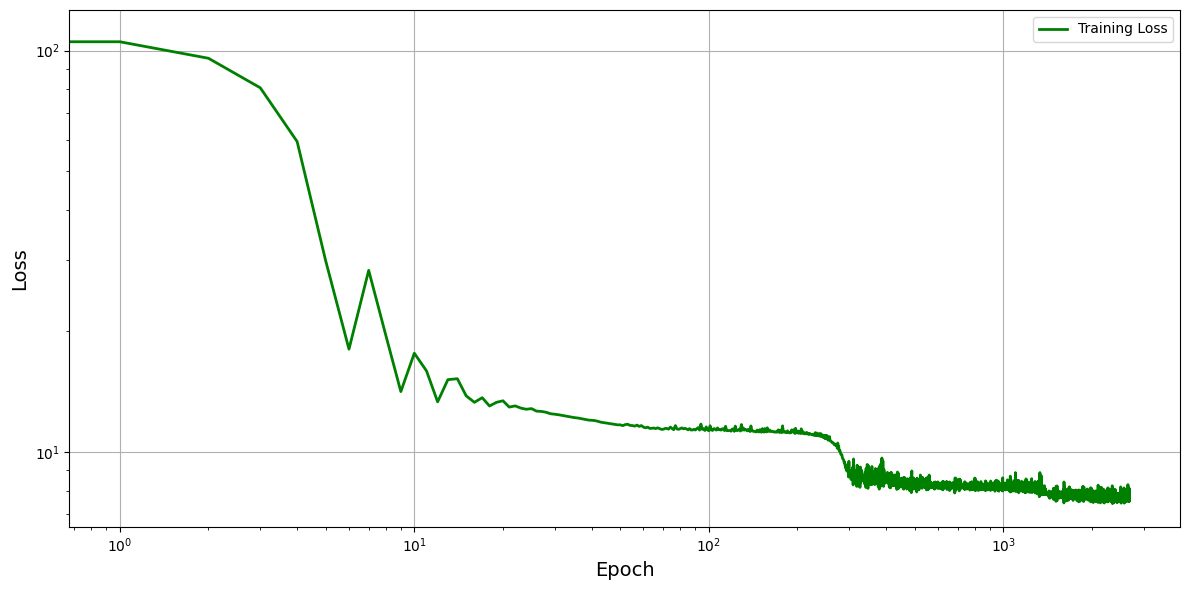

In [2]:
plt.figure(figsize=(12,6))

plt.errorbar(z, H_mock, yerr=sigma, fmt='o', markersize=4, alpha=0.6, label='Mock Data', color ='purple')
plt.errorbar(z, df['H(z)'], yerr=sigma, fmt='o', markersize=4, alpha=0.6, label='Real Data', color ='green')
plt.plot(z_grid, H_real, linewidth=3, label='True Cosmology')
#plt.plot(z_grid, H_pred, linewidth=3, label='ANN Reconstruction', color = 'green')
plt.xlabel("Redshift z", fontsize=14)
plt.ylabel(r"$H(z)$", fontsize=14)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# LOSS
plt.figure(figsize=(12,6))

plt.plot(history.history['loss'],linewidth=2,label='Training Loss', color ='green')
#plt.plot(history.history['val_loss'],linewidth=2,label='Validation Loss')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

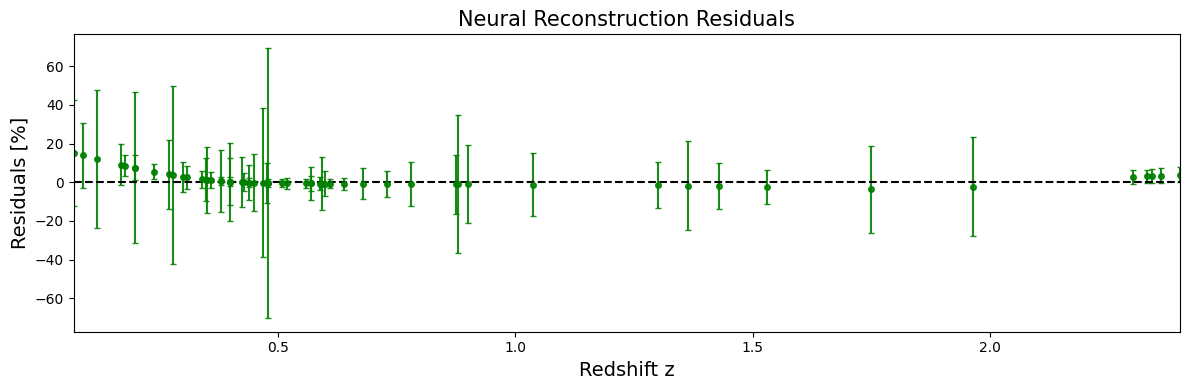

In [3]:
# Residuals
H_pred = model(z_grid.reshape(-1,1),training=False).numpy().flatten()

relative_residuals = 100 * (H_pred - H_real) / H_real

smooth_residuals = savgol_filter(relative_residuals,51,3)

H_points_pred = model(z.reshape(-1,1),training=False).numpy().flatten()

point_residuals = 100 * (H_points_pred - H_true) / H_true

point_errors = 100 * sigma / H_true


plt.figure(figsize=(12,4))

plt.errorbar(z,point_residuals,yerr=point_errors,fmt='o',markersize=4,capsize=2,alpha=0.9,color='green')
plt.axhline(0,linestyle='--',linewidth=1.5,color='black')
plt.xlabel('Redshift z',fontsize=14)
plt.ylabel('Residuals [%]',fontsize=14)
plt.title('Neural Reconstruction Residuals',fontsize=15)
plt.margins(x=0)
plt.tight_layout()
plt.show()

In [8]:
H = df["H(z)"].values


idx = np.random.permutation(len(z))

split = int(0.95 * len(z))

train = idx[:split]
test  = idx[split:]

X_train = z[train].reshape(-1,1)
y_train = H[train]

X_test = z[test].reshape(-1,1)
y_test = H[test]


# Neural Network

model = Sequential([

    Input(shape=(1,)),

    Dense(256, activation='elu'),
    Dense(256, activation='elu'),
    Dense(256, activation='elu'),

    Dense(1)])

model.compile(optimizer='adam',loss='mae')



# Early stopping


early_stop = EarlyStopping(monitor='val_loss',patience=300,restore_best_weights=True)



# Training


history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=5000,

    batch_size=16,

    verbose=0,

    callbacks=[TqdmCallback(verbose=1),early_stop])


# Reconstruction

z_grid = np.linspace(z.min(), z.max(), 1000).reshape(-1,1)

H_rec = model.predict(z_grid, verbose=0).flatten()

 42%|████▏     | 2109/5000 [03:08<04:18, 11.20epoch/s, loss=5.94, val_loss=5.32]


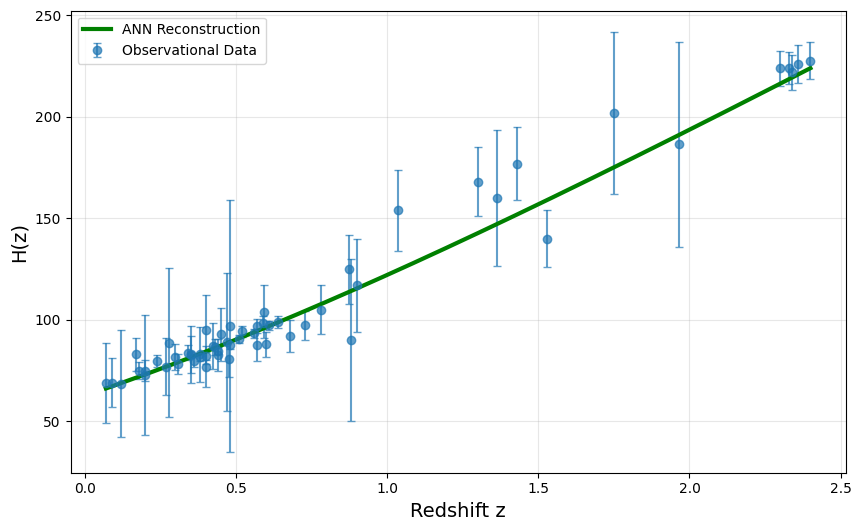

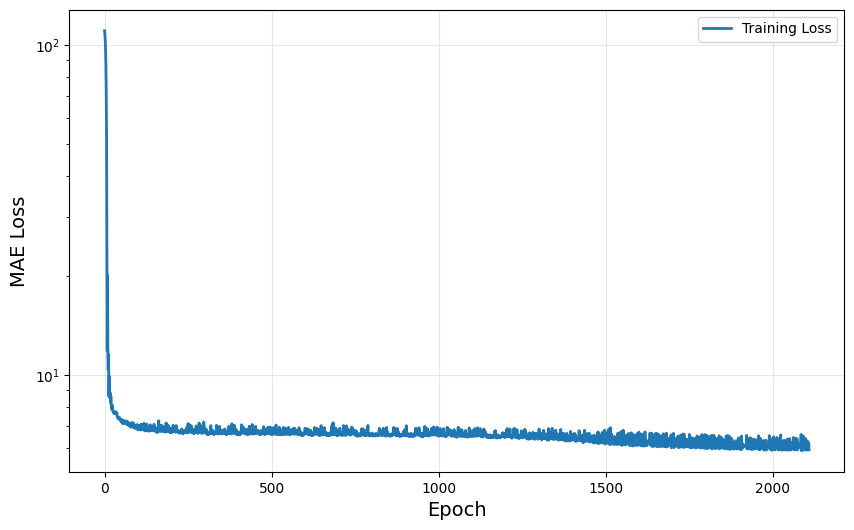

In [9]:
# Reconstruction Graphic
plt.figure(figsize=(10,6))

plt.errorbar(z,H,yerr=df["σH"].values,fmt='o',capsize=3,alpha=0.7,label='Observational Data')
plt.plot(z_grid,H_rec,linewidth=3,label='ANN Reconstruction', color='green')
plt.xlabel("Redshift z", fontsize=14)
plt.ylabel("H(z)", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Loss Graphic
plt.figure(figsize=(10,6))

plt.plot(history.history['loss'],linewidth=2,label='Training Loss')
#plt.plot(history.history['val_loss'],linewidth=2,label='Validation Loss')
plt.yscale('log')
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("MAE Loss", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()